# Train a KIND model on detuning data

To respect our Kalman filter baseline, the nominal model of KIND is restricted to 3 sinusoidal basis functions. The transient operator has 5 sinusoidal functions, which still turns out to be too restrictive.

In [1]:
# --! include root folder into PYTHONPATH

import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..'))
sys.path.append(root_dir)

data_dir = '../../data/kalman'
model_dir = '../../models/kalman'

# --! import Python libraries and KIND framework files

import torch
import numpy as np
from matplotlib import pyplot as plt

import kind
import util_data
import util_nn
import example_kalman

In [2]:
# --! initialize random seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[3]

util_nn.set_seed(seed)

print(f'setting seed {seed}')

setting seed 8192


In [3]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', data_dir,
        '--file_name', 'kalman',
        '--data_nsample_baseline', '5000',
        '--data_nsample_nom', '144',
        '--data_nsample_exc', '144',
        '--obs_ndim', '1',
        '--act_ndim', '0',
        '--target_ndim', '1',
        '--data_train_size', '0.8',

        '--back_nsample', '96',
        '--fore_nsample', '48',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', model_dir,

        '--rez_nsample_nom', '48',
        '--rez_nsample_exc', '12',
        '--embed_nom', '{"sin": 3, "cos": 3}',
        '--embed_exc', '{"sin": 5, "cos": 5}',
    ]
)

setpoint = torch.tensor([0.0])

In [4]:
# --! create model, dataset and training

model = kind.model(args)
dataset = example_kalman.dataset(args, setpoint, load_normalized=True, extract_windows=False)
training = kind.training(model)

In [5]:
# --! compute model capacity

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of trainable parameters: {nparam/1e6}M')

number of trainable parameters: 0.399298M


## Train nominal model

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.145923, valid=0.136679, test=0.138964
	validation loss decreased (inf -> 0.136679), saving model ...
	epoch 2 losses: train=0.139607, valid=0.135697, test=0.137677
	validation loss decreased (0.136679 -> 0.135697), saving model ...
	epoch 3 losses: train=0.139096, valid=0.135534, test=0.137632
	validation loss decreased (0.135697 -> 0.135534), saving model ...
	epoch 4 losses: train=0.138954, valid=0.135480, test=0.137417
	validation loss decreased (0.135534 -> 0.135480), saving model ...
	epoch 5 losses: train=0.138859, valid=0.135326, test=0.137450
	validation loss decreased (0.135480 -> 0.135326), saving model ...
	epoch 6 losses: train=0.138834, valid=0.135349, test=0.137382
	early stopping counter: 1 out of 100
	epoch 7 losses: train=0.138761, valid=0.135219, test=0.137287
	validation loss decreased (0.135326 -> 0.135219), saving model ...
	epoch 8 losses: train=0.138413, valid=0.134480, test=0.136484
	validation loss decrease

## Evaluate nominal model

In [7]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

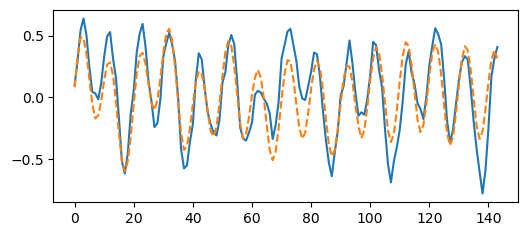

In [8]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :1])
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')

        plt.show()

        break

## Train nominal uncertainty

In [9]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=3.370781, valid=2.756190, test=3.258830
	validation loss decreased (inf -> 2.756190), saving model ...
	epoch 2 losses: train=3.283219, valid=2.698064, test=3.188551
	validation loss decreased (2.756190 -> 2.698064), saving model ...
	epoch 3 losses: train=3.200876, valid=2.645306, test=3.184655
	validation loss decreased (2.698064 -> 2.645306), saving model ...
	epoch 4 losses: train=3.173712, valid=2.655686, test=3.073080
	early stopping counter: 1 out of 100
	epoch 5 losses: train=3.196168, valid=2.664225, test=3.097826
	early stopping counter: 2 out of 100
	epoch 6 losses: train=3.137146, valid=2.679138, test=3.067301
	early stopping counter: 3 out of 100
	epoch 7 losses: train=3.107600, valid=2.565293, test=3.078089
	validation loss decreased (2.645306 -> 2.565293), saving model ...
	epoch 8 losses: train=3.128020, valid=2.608072, test=3.037387
	early stopping counter: 1 out of 100
	epoch 9 losses: train=3.102834, valid=2

## Evaluate nominal uncertainty

In [10]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

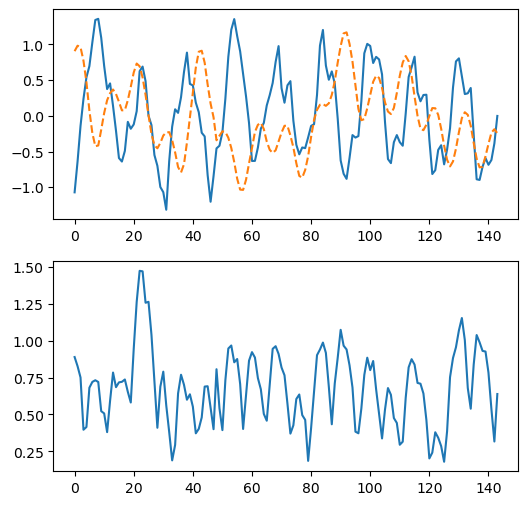

In [11]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :1])

        plt.show()

        break

## Train excursion model

In [12]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=1.934861, valid=1.762039, test=1.976431
	validation loss decreased (inf -> 1.762039), saving model ...
	epoch 2 losses: train=1.880561, valid=1.664875, test=1.873267
	validation loss decreased (1.762039 -> 1.664875), saving model ...
	epoch 3 losses: train=1.569589, valid=1.239556, test=1.398548
	validation loss decreased (1.664875 -> 1.239556), saving model ...
	epoch 4 losses: train=1.149472, valid=0.895821, test=0.946774
	validation loss decreased (1.239556 -> 0.895821), saving model ...
	epoch 5 losses: train=0.753042, valid=0.637418, test=0.638617
	validation loss decreased (0.895821 -> 0.637418), saving model ...
	epoch 6 losses: train=0.545331, valid=0.517803, test=0.497098
	validation loss decreased (0.637418 -> 0.517803), saving model ...
	epoch 7 losses: train=0.479618, valid=0.480792, test=0.456113
	validation loss decreased (0.517803 -> 0.480792), saving model ...
	epoch 8 losses: train=0.445461, valid=0.468731, test=0.

## Evaluate excursion model

In [13]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

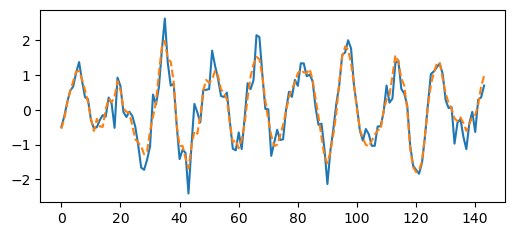

In [14]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

## Train excursion uncertainty

In [15]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.096248, valid=0.083364, test=0.083565
	validation loss decreased (inf -> 0.083364), saving model ...
	epoch 2 losses: train=0.083562, valid=0.082102, test=0.082392
	validation loss decreased (0.083364 -> 0.082102), saving model ...
	epoch 3 losses: train=0.082882, valid=0.081706, test=0.081979
	validation loss decreased (0.082102 -> 0.081706), saving model ...
	epoch 4 losses: train=0.082659, valid=0.081477, test=0.081760
	validation loss decreased (0.081706 -> 0.081477), saving model ...
	epoch 5 losses: train=0.082396, valid=0.081345, test=0.081614
	validation loss decreased (0.081477 -> 0.081345), saving model ...
	epoch 6 losses: train=0.082276, valid=0.081257, test=0.081542
	validation loss decreased (0.081345 -> 0.081257), saving model ...
	epoch 7 losses: train=0.082264, valid=0.081223, test=0.081497
	validation loss decreased (0.081257 -> 0.081223), saving model ...
	epoch 8 losses: train=0.082523, valid=0.081186, 

## Evaluate excursion uncertainty

In [16]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

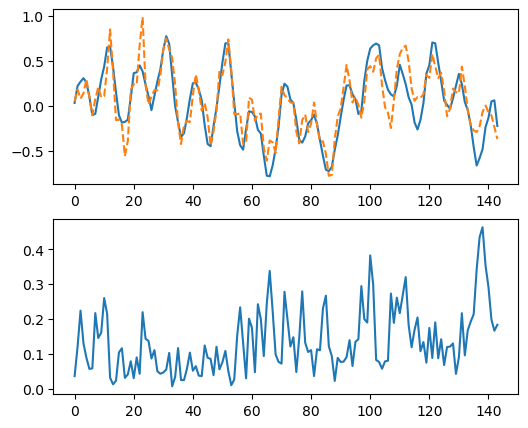

In [17]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

## Evaluate KIND blending

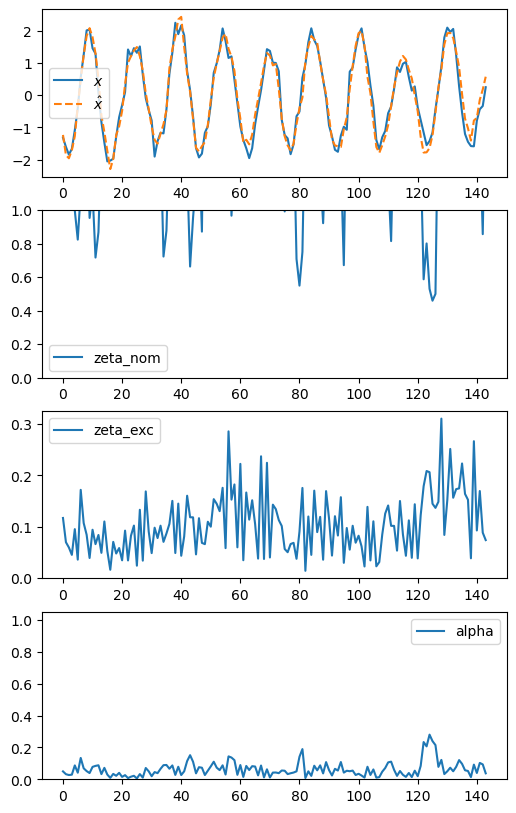

In [18]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='$x$')
        plt.plot(pre[0, :, :1], linestyle='dashed', label='$\\hat{x}$')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break